# AnswerMap on GPT-6 through the API

Get a map of where the model looks for your query, on your own image, using only the API's first-token logprobs.

1. Add your key: **Secrets** (key icon, left sidebar) → name `OPENAI_API_KEY`, turn on notebook access. Or paste it when asked.
2. **Runtime → Run all**, then choose an image and type a query.

In [1]:
!git clone -q https://github.com/sanataff/AnswerMap.git
%cd AnswerMap
!pip install -q -U openai

/content/AnswerMap
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 24.9 MB/s eta 0:00:00


In [11]:
import os
from openai import OpenAI

try:
    from google.colab import userdata
    os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
except Exception:
    pass
if not os.environ.get("OPENAI_API_KEY"):
    from getpass import getpass
    os.environ["OPENAI_API_KEY"] = getpass("OpenAI API key: ")

client = OpenAI()
MODEL = "gpt-6-sol"      # or "gpt-6-luna" (cheaper)
KS = (4, 5, 9, 11)       # multigrid: 2 x (4+5+9+11) = 58 calls per map

## The model as the AnswerMap backend

The map only needs P(yes) for each band question, read from the first-token logprobs.

In [12]:
import base64, io, math
from concurrent.futures import ThreadPoolExecutor
from AnswerMap.answermap import YESNO_PROMPT

# GPT-6 returns logprobs only with reasoning off
EXTRA = {"reasoning_effort": "none"} if MODEL.startswith("gpt-6") else {}

def to_url(im):
    buf = io.BytesIO(); im.convert("RGB").save(buf, format="PNG")
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()

class GPTBackend:
    def __init__(self, model):
        self.model, self.calls = model, 0

    def p_yes(self, imgs, cond):
        content = [{"type": "image_url", "image_url": {"url": to_url(im), "detail": "high"}} for im in imgs]
        content.append({"type": "text", "text": YESNO_PROMPT.format(cond=cond)})
        r = client.chat.completions.create(
            model=self.model, messages=[{"role": "user", "content": content}],
            max_completion_tokens=50, logprobs=True, top_logprobs=5, **EXTRA)
        yes = no = 0.0
        for t in r.choices[0].logprobs.content[0].top_logprobs:
            w = t.token.strip().lower()
            if w == "yes": yes += math.exp(t.logprob)
            if w == "no": no += math.exp(t.logprob)
        return yes / (yes + no) if yes + no else 0.5

    def p_yes_batch(self, img_lists, cond):
        with ThreadPoolExecutor(8) as ex:   # band questions are independent
            out = list(ex.map(lambda imgs: self.p_yes(imgs, cond), img_lists))
        self.calls += len(out)
        return out

vlm = GPTBackend(MODEL)

## Your image and query

In [14]:
from google.colab import files

print("Choose an image:")
IMAGE = list(files.upload())[0]
QUERY = input("Query (e.g. 'the red car'): ")

Choose an image:


Saving beacon_orig.png to beacon_orig (1).png
Query (e.g. 'the red car'): the beacon


## Run

query: 'the beacon'
query: 'the beacon'
query: 'the beacon'
query: 'the beacon'
query: 'the beacon'


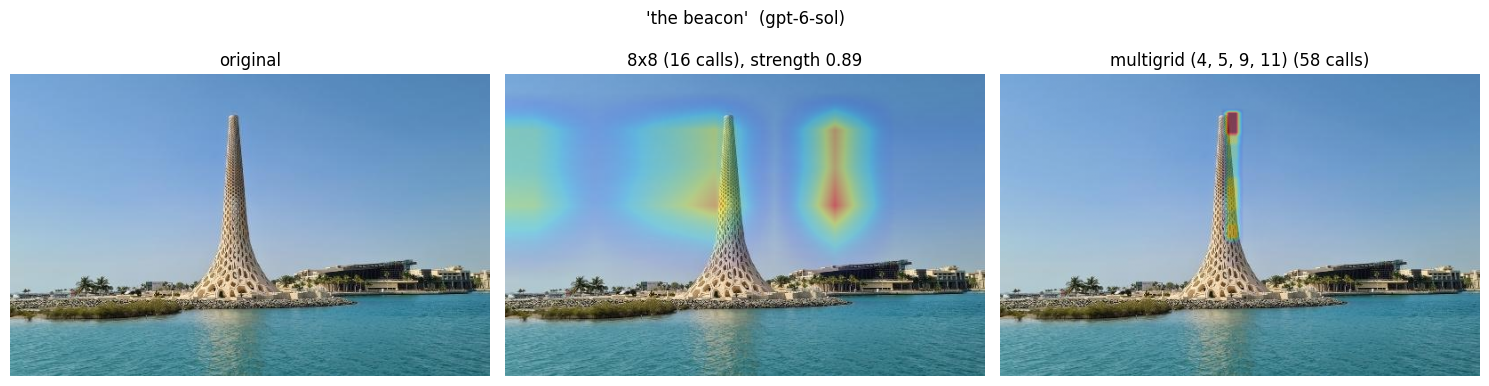

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from AnswerMap.answermap import Config, load_image, probe, multigrid_map

cfg = Config(model_name=MODEL, K=8)
orig = Image.open(IMAGE).convert("RGB")
small = load_image(IMAGE, 512)

M8 = probe(vlm, small, QUERY, cfg)["M"]              # 8x8 grid, 16 calls
MG = multigrid_map(vlm, small, QUERY, cfg, Ks=KS)     # multigrid, 58 calls

def overlay(M):
    m = np.asarray(Image.fromarray((np.clip(M, 0, 1) * 255).astype(np.uint8))
                   .resize(orig.size, Image.BILINEAR)) / 255.0
    a = 0.6 * m[..., None]
    return np.asarray(orig) / 255.0 * (1 - a) + plt.get_cmap("jet")(m)[..., :3] * a

fig, axes = plt.subplots(1, 3, figsize=(15, 5 * orig.height / orig.width + 1))
for ax, im, t in zip(axes, (orig, overlay(M8), overlay(MG)),
                     ("original", f"8x8 (16 calls), strength {M8.max():.2f}", f"multigrid {KS} (58 calls)")):
    ax.imshow(im); ax.set_title(t); ax.axis("off")
fig.suptitle(f"{QUERY!r}  ({MODEL})"); plt.tight_layout(); plt.show()
